In [1]:
55+66


121

### Problem Statement:

- Develop a machine learning classification model that predicts an individual's obesity level (NObeyesdad) based on demographic information, physical characteristics, eating habits, and lifestyle factors such as physical activity, water intake, smoking habits, and transportation type.

- Analyze lifestyle and health-related features of individuals.

- Train a supervised machine learning classification model.

- Predict the obesity category of a person.

## 1.step : Import the libraries and Load thedataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
ds = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
ds.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
ds.shape

(2111, 17)

In [7]:
ds.keys()

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

## Data cleaning (EDA)

In [8]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [9]:
# checking for duplicates
ds.duplicated().sum()

np.int64(24)

In [10]:
# dropping duplicates


ds = ds.drop_duplicates()
ds.duplicated().sum()

np.int64(0)

In [11]:
# Checking for null values
ds.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [14]:
ds.shape

(2087, 17)

In [12]:
# changing data types of categorical features to category

ds = ds.astype({
    'Gender': 'category',
    'family_history_with_overweight': 'category',
    'FAVC': 'category',
    'CAEC': 'category',
    'SMOKE': 'category',
    'SCC': 'category',
    'CALC': 'category',
    'MTRANS': 'category',
    'NObeyesdad': 'category'
})

In [13]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          2087 non-null   category
 1   Age                             2087 non-null   float64 
 2   Height                          2087 non-null   float64 
 3   Weight                          2087 non-null   float64 
 4   family_history_with_overweight  2087 non-null   category
 5   FAVC                            2087 non-null   category
 6   FCVC                            2087 non-null   float64 
 7   NCP                             2087 non-null   float64 
 8   CAEC                            2087 non-null   category
 9   SMOKE                           2087 non-null   category
 10  CH2O                            2087 non-null   float64 
 11  SCC                             2087 non-null   category
 12  FAF                      

### Class Distribution (Target Variable)

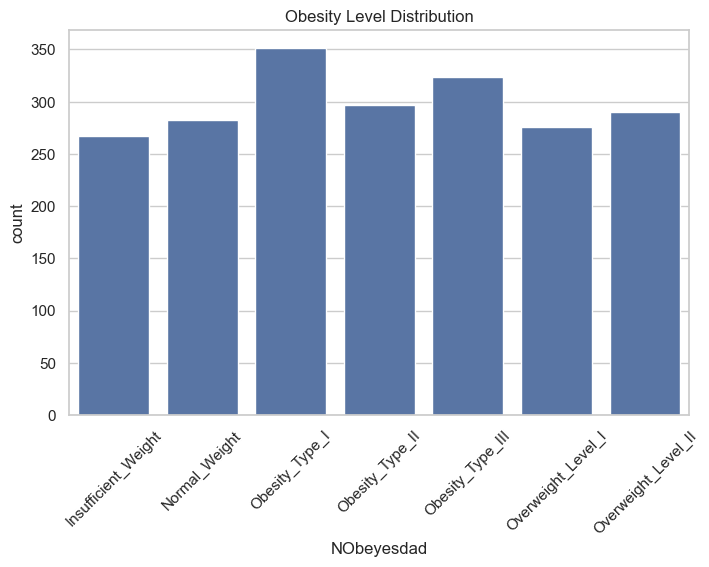

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='NObeyesdad', data=ds)
plt.xticks(rotation=45)
plt.title("Obesity Level Distribution")
plt.show()

### Weight Distribution

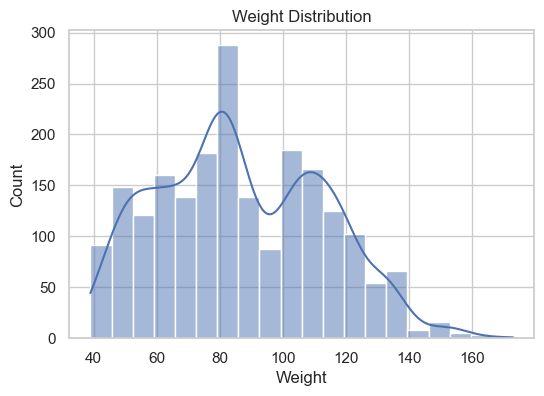

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(ds['Weight'], bins=20, kde=True)
plt.title("Weight Distribution")
plt.show()

### Height vs Weight Scatter Plot

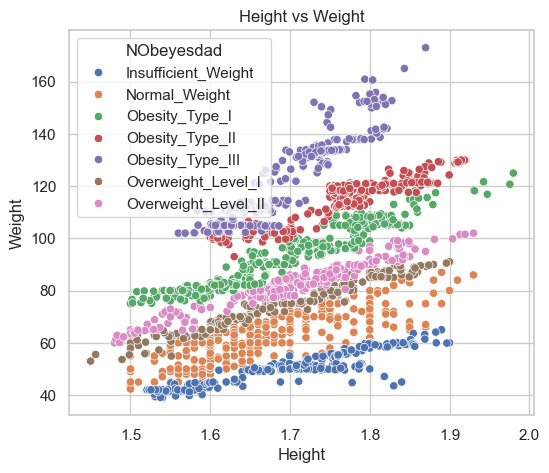

In [17]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Height', y='Weight', hue='NObeyesdad', data=ds)
plt.title("Height vs Weight")
plt.show()

### Physical Activity vs Obesity

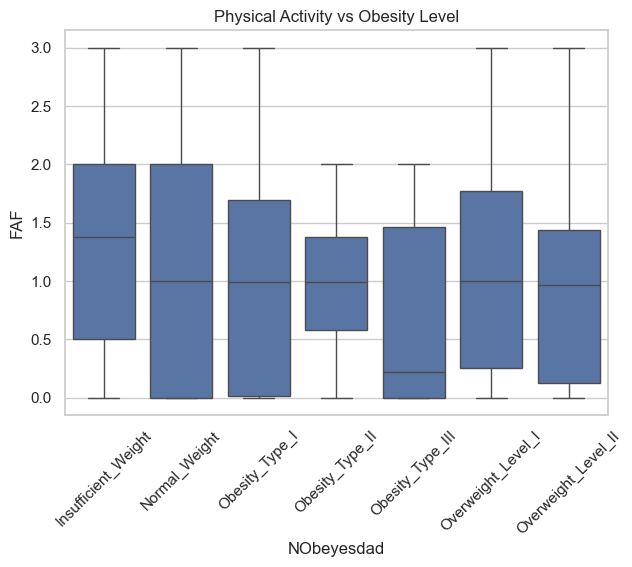

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(x='NObeyesdad', y='FAF', data=ds)
plt.xticks(rotation=45)
plt.title("Physical Activity vs Obesity Level")
plt.show()

### High Calorie Food vs Obesity

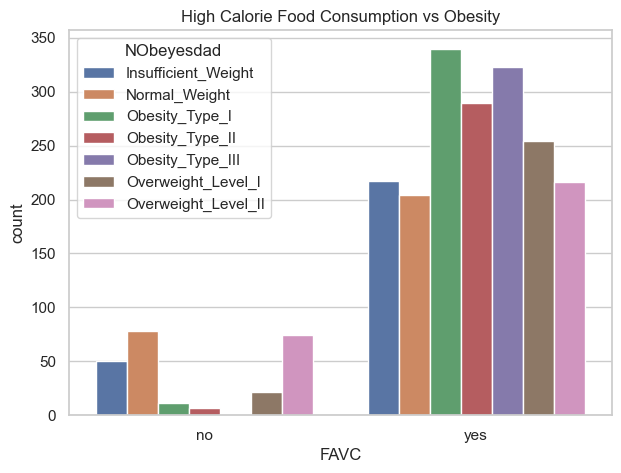

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(x='FAVC', hue='NObeyesdad', data=ds)
plt.title("High Calorie Food Consumption vs Obesity")
plt.show()

## checking for outliers
 - using boxplot
- if outliers are present then we deal with  Before handling them, we identify where outliers exist.
Common methods
1. Box Plot, z-score method
- Uses IQR (Inter Quartile Range).
- Values outside whiskers are considered outliers.
- Formula: IQR=Q3−Q1
- Outlier conditions:

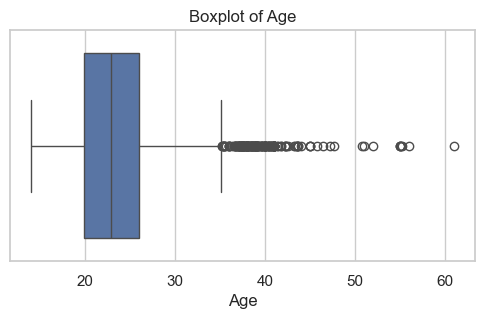

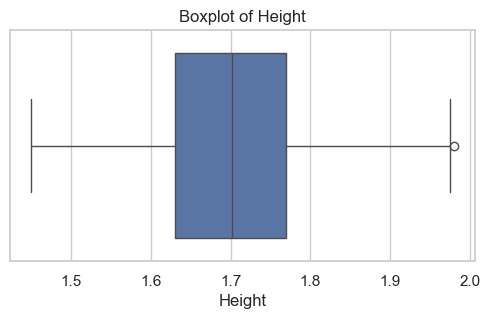

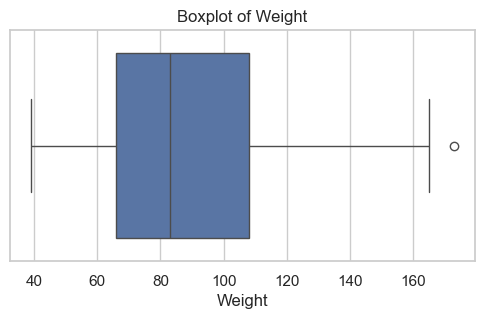

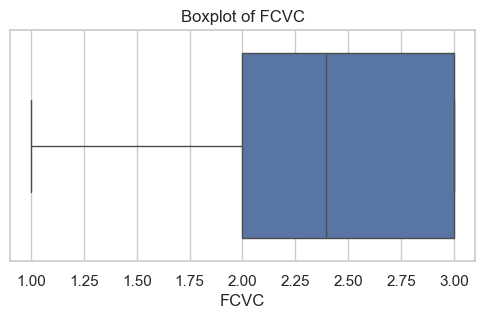

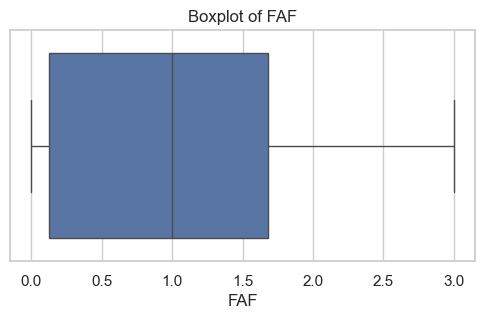

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Height','Weight','FCVC','FAF']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=ds[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Correlation Heatmap (Very Important)

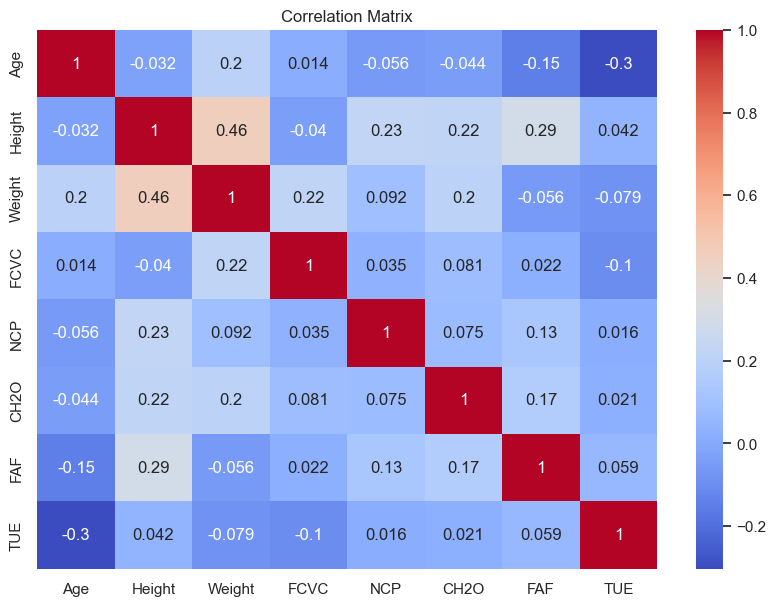

In [21]:
plt.figure(figsize=(10,7))

numeric_ds = ds.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_ds.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

### Target Variable

`NObeyesdad`

This column represents the obesity level, which may include categories like:

- Insufficient_Weight

- Normal_Weight

- Overweight_Level_I

- Overweight_Level_II

- Obesity_Type_I

- Obesity_Type_II

- Obesity_Type_III

So this becomes a Multi-Class Classification Problem.

In [23]:
# Select target variable
y = ds['NObeyesdad']

# Drop target column from dataset to create features
X = ds.drop(columns=['NObeyesdad'])

# Check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2087, 16)
Target shape: (2087,)


### Input Features (Independent Variables)

Some important predictors in the dataset include:


- Age

- Height

- Weight

- family_history_with_overweight

- FAVC (Frequent high-calorie food consumption)

- FAF (Physical activity frequency)


In [24]:
selected_features = [
    'Age',
    'Height',
    'Weight',
    'family_history_with_overweight',
    'FAF',
    'FAVC'
]

X = ds[selected_features]
y = ds['NObeyesdad']

In [25]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Encode Binary Columns

- Since family_history_with_overweight and FAVC contain yes/no, convert them to numbers.

In [26]:
X['family_history_with_overweight'] = X['family_history_with_overweight'].map({'yes':1, 'no':0})
X['FAVC'] = X['FAVC'].map({'yes':1, 'no':0})

C:\Users\saira\AppData\Local\Temp\ipykernel_17052\783617767.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['family_history_with_overweight'] = X['family_history_with_overweight'].map({'yes':1, 'no':0})
C:\Users\saira\AppData\Local\Temp\ipykernel_17052\783617767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['FAVC'] = X['FAVC'].map({'yes':1, 'no':0})


In [27]:
X.head()

,Age,Height,Weight,family_history_with_overweight,FAF,FAVC
0,21.0,1.62,64.0,1,0.0,0
1,21.0,1.52,56.0,1,3.0,0
2,23.0,1.80,77.0,1,2.0,0
3,27.0,1.80,87.0,0,2.0,0
4,22.0,1.78,89.8,0,0.0,0


#### Encode the target column:

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

### Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1669, 6)
Testing data: (418, 6)


### Model Training

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [32]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000, random_state=42)

LR_model.fit(X_train, y_train)

d:\innomatics\ML_Projects\mlproject\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
DT_model = DecisionTreeClassifier(random_state=42)
DT_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [34]:
RF_model = RandomForestClassifier(random_state=42)
RF_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
LR_pred = LR_model.predict(X_test)
DT_pred = DT_model.predict(X_test)
RF_pred = RF_model.predict(X_test)

### Model Evaluation

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, model_name):
    
    print(f"\n{model_name} Performance")
    
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))


evaluate_model(y_test, LR_pred, "Logistic Regression")
evaluate_model(y_test, DT_pred, "Decision Tree")
evaluate_model(y_test, RF_pred, "Random Forest")


Logistic Regression Performance
Accuracy: 0.7607655502392344
Precision: 0.7666085882857845
Recall: 0.7607655502392344
F1 Score: 0.7529932687335835

Decision Tree Performance
Accuracy: 0.9401913875598086
Precision: 0.9401186153161738
Recall: 0.9401913875598086
F1 Score: 0.9399733512297052

Random Forest Performance
Accuracy: 0.9449760765550239
Precision: 0.946020579991847
Recall: 0.9449760765550239
F1 Score: 0.945021422041685


### Hyperparameter Tuning

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


In [38]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred))

Tuned Model Accuracy: 0.9449760765550239


### saving the model into pickel file for deployment

In [40]:
import joblib

joblib.dump(RF_model, "obesity_rf_model.pkl")
joblib.dump(le, "obesity_label_encoder.pkl")

['obesity_label_encoder.pkl']